# Loan Default Prediction

## Project Overview

This notebook builds an **end-to-end machine learning pipeline** to predict whether a borrower will default on a loan. Accurate default prediction helps financial institutions:

- Minimise credit risk and financial losses
- Make fairer, data-driven lending decisions
- Flag high-risk applicants before loan approval

**Approach:**
1. Exploratory Data Analysis (EDA) — understand distributions, class balance, and feature relationships
2. Feature Engineering — create meaningful derived features
3. Modelling — train an optimised XGBoost classifier with 5-fold stratified cross-validation
4. Threshold Tuning — maximise F1-score using precision-recall analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [5]:
train_path =r"C:\Users\asus\Desktop\DATA C'EPT\Projects\Loan_Prediction_project\train.csv"
test_path  =r"C:\Users\asus\Desktop\DATA C'EPT\Projects\Loan_Prediction_project\test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (58645, 13)
Test shape: (39098, 12)


In [6]:
train_df.head()


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


### Dataset Overview

The dataset contains **borrower profile features** and **loan characteristics**. Each row is one loan application and the target column `loan_status` indicates whether the borrower defaulted (1) or not (0).

Key feature groups:

| Group | Features |
|---|---|
| **Borrower profile** | `person_age`, `person_income`, `person_emp_length`, `person_home_ownership` |
| **Loan details** | `loan_amnt`, `loan_intent`, `loan_grade`, `loan_int_rate`, `loan_percent_income` |
| **Credit history** | `cb_person_default_on_file`, `cb_person_cred_hist_length` |
| **Target** | `loan_status` (0 = no default, 1 = default) |

In [12]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

### Data Types & Memory

- Most numerical features are stored as `float64` / `int64` — suitable for modelling.
- Categorical columns (`person_home_ownership`, `loan_intent`, `loan_grade`, `cb_person_default_on_file`) will need encoding before training.
- Check above for any `object` columns with unexpected types that might require manual parsing.

In [11]:
print(train_df.isnull().sum())

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64


### Missing Values

A few features — notably `person_emp_length` and `loan_int_rate` — typically have some missing entries in this dataset.

**Strategy:**
- For numerical features: impute with **median** (robust to outliers).
- For categorical features: impute with **mode** or a dedicated "Unknown" category.

> Tree-based models like XGBoost can handle missing values natively during training, but explicit imputation ensures consistency across the preprocessing pipeline.

In [13]:
print(train_df["loan_status"].value_counts())

loan_status
0    50295
1     8350
Name: count, dtype: int64


### Target Variable — `loan_status` Distribution

The dataset is **imbalanced**: the majority of loans are not defaulted. This is expected in real-world lending data.

**Implications:**
- A naive model predicting "no default" for everyone would achieve high accuracy but be useless.
- We use **Stratified K-Fold** cross-validation to preserve the class ratio in each fold.
- Evaluation focuses on **F1-score** and **recall for defaulters** rather than raw accuracy, since missing a true default is costlier than a false alarm.

---
## 3. Exploratory Data Analysis (EDA)

EDA reveals patterns in the data that guide feature engineering and model design. We analyse:
- **Categorical features** via count plots
- **Numerical features** via histograms and KDE curves
- **Descriptive statistics** to spot skew and outliers

### 3.1 Categorical Features — Count Plots

Count plots show the **frequency of each category**. We look for:
- Dominant categories that might introduce bias
- Rare categories that could hurt generalisation
- Categories that intuitively relate to creditworthiness (e.g., loan grade, home ownership)

In [15]:
categorical_columns=["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]
for col in categorical_columns:
    print(col, train_df[col].unique())
    print("-"*50)

person_home_ownership ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
--------------------------------------------------
loan_intent ['EDUCATION' 'MEDICAL' 'PERSONAL' 'VENTURE' 'DEBTCONSOLIDATION'
 'HOMEIMPROVEMENT']
--------------------------------------------------
loan_grade ['B' 'C' 'A' 'D' 'E' 'F' 'G']
--------------------------------------------------
cb_person_default_on_file ['N' 'Y']
--------------------------------------------------


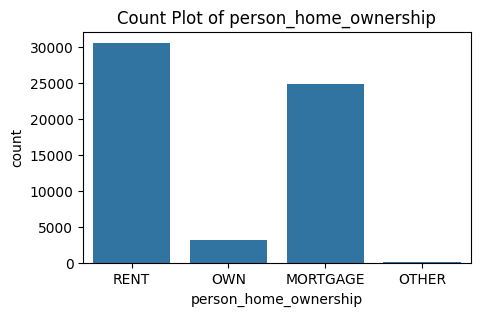

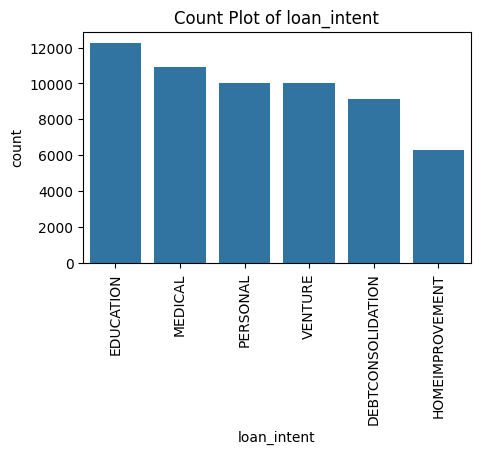

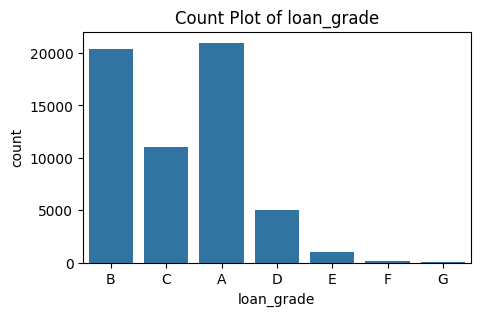

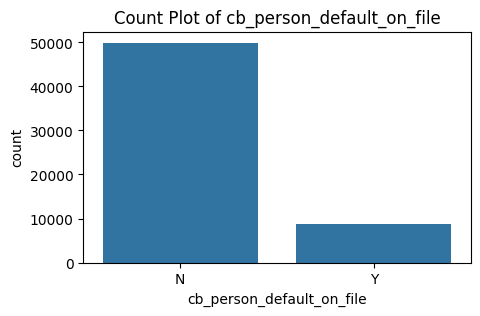

In [20]:
for col in categorical_columns:
  plt.figure(figsize=(5,3))
  sns.countplot(data=train_df,x=col)
  plt.title(f"Count Plot of {col}")
  if col=="loan_intent":
    plt.xticks(rotation=90)
  plt.show()

**Categorical Features — Key Observations:**

| Feature | Observation | Insight |
|---|---|---|
| `person_home_ownership` | RENT and MORTGAGE dominate | Renters may have less financial stability |
| `loan_intent` | Education and medical loans are common | Intent may signal financial stress or urgency |
| `loan_grade` | Grade A and B are most frequent | Lower grades (D–G) likely correlate strongly with default |
| `cb_person_default_on_file` | Most have no prior default on file | Prior default history is a strong risk signal |

> `loan_grade` is encoded as an **ordinal** variable (A=1 to G=7) in the feature engineering step, preserving the natural risk ranking.

### 3.2 Numerical Features — Summary Statistics

`describe()` gives us the central tendency (mean, median) and spread (std, min, max) for each numerical column. We look for:
- **High standard deviation** → wide spread, potential outliers
- **Gap between mean and median** → skewed distribution
- **Unrealistic extremes** → possible data entry errors

In [21]:
train_df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


**Summary Statistics — Key Observations:**

| Feature | Observation |
|---|---|
| `person_age` | Some extreme values (e.g. age > 100) — likely outliers to watch |
| `person_income` | Highly right-skewed; very high earners pull the mean up |
| `person_emp_length` | Ranges 0–123 years — values above ~50 are likely errors |
| `loan_amnt` | Wide range; large loans likely correlate with default risk |
| `loan_int_rate` | Higher rates signal riskier borrowers (correlated with loan grade) |
| `loan_percent_income` | Debt-to-income proxy; high values indicate financial strain |

### 3.3 Numerical Features — Distributions (Histograms + KDE)

We plot a histogram with KDE (Kernel Density Estimate) for each numerical feature to visualise:
- **Shape** (normal, skewed, bimodal)
- **Outliers** (long tails)
- **Natural clusters** (potential for binning / feature engineering)

In [ ]:
def plot_histogram(df,column_name):
  plt.figure(figsize=(5,3))
  sns.histplot(df[column_name],kde=True)
  plt.title(f"Distribution of {column_name}")

  col_mean=df[column_name].mean()
  col_median=df[column_name].median()

  plt.axvline(col_mean,color="red",linestyle="--",label="Mean")
  plt.axvline(col_median,color="green",linestyle="-",label="Median")

  plt.show()

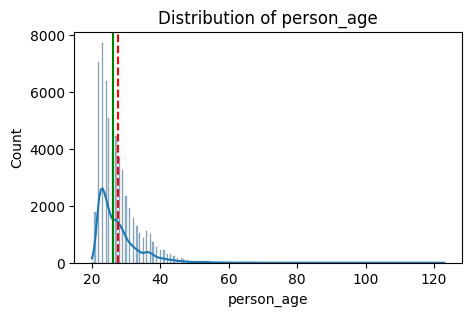

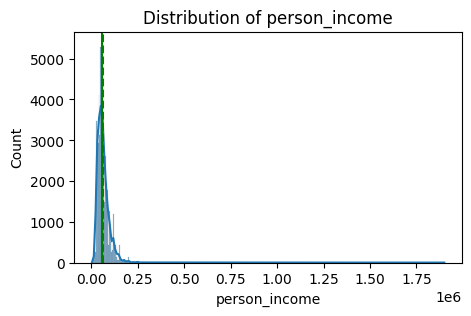

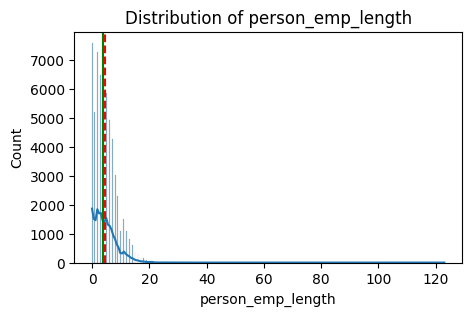

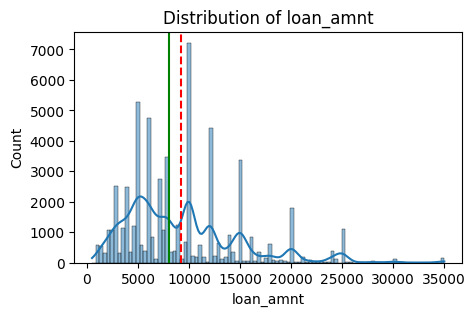

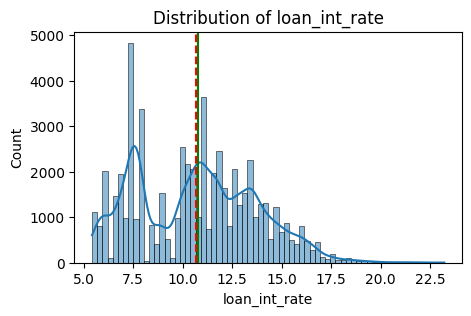

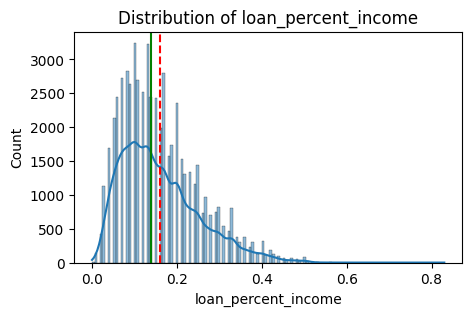

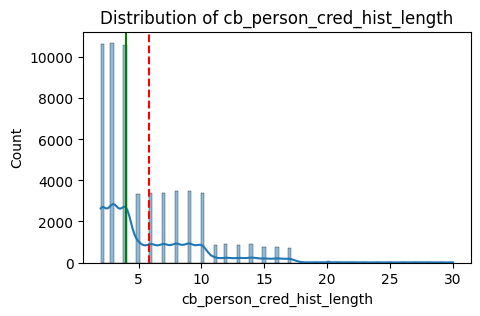

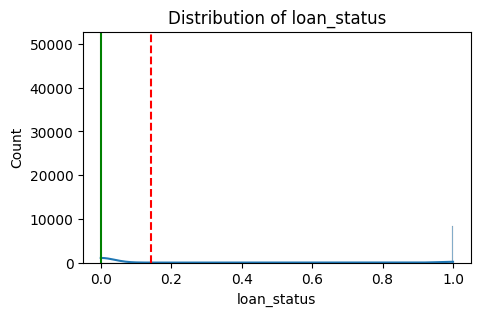

In [ ]:
for col in train_df.columns:
    if (col not in categorical_columns)&(col!='id'):
        plot_histogram(train_df,col)

**Distribution Insights:**

- **`person_age`**: Right-skewed with most borrowers aged 20–40. A few extreme values (age > 80) should be capped.
- **`person_income`**: Strongly right-skewed — log transformation or capping extreme values may help linear models (not required for XGBoost).
- **`person_emp_length`**: Bimodal, with peaks at 0–2 years and 5+ years. This motivates the `long_employment` binary feature.
- **`loan_amnt`**: Roughly uniform with slight right skew — a wide range of loan sizes requested.
- **`loan_int_rate`**: Peaks around 10–15%; high-rate loans (>20%) are likely riskiest.
- **`loan_percent_income`**: Most values cluster below 0.2 (20% of income); values above 0.4 represent high-burden borrowers.
- **`cb_person_cred_hist_length`**: Right-skewed — most borrowers have shorter credit histories (younger applicants).

---
## 4. Feature Engineering

Raw features capture only part of the story. We engineer new features that better express financial risk signals:

In [4]:
def create_new_features(df):
    df = df.copy()

    df['income_loan_ratio'] = df['person_income'] / (df['loan_amnt'] + 1)
    df['dti_ratio'] = df['loan_percent_income'] * 100

    df['age_group'] = pd.cut(
        df['person_age'],
        bins=[0, 25, 35, 45, 60, 100],
        labels=['18-25', '26-35', '36-45', '46-60', '60+']
    )

    df['long_employment'] = (df['person_emp_length'] >= 5).astype(int)
    df['high_income'] = (df['person_income'] > 75000).astype(int)

    grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df['loan_grade_score'] = df['loan_grade'].map(grade_mapping)

    return df

train_df = create_new_features(train_df)
test_df  = create_new_features(test_df)


skewed = [
    'person_income',
    'loan_amnt',
    'income_loan_ratio',
    'cb_person_cred_hist_length'
]

for col in skewed:
    train_df[col] = np.log1p(train_df[col])
    test_df[col]  = np.log1p(test_df[col])


train_df['interest_to_loan'] = train_df['loan_int_rate'] / (train_df['loan_amnt'] + 1)
test_df['interest_to_loan']  = test_df['loan_int_rate'] / (test_df['loan_amnt'] + 1)

train_df['credit_per_age'] = train_df['cb_person_cred_hist_length'] / (train_df['person_age'] + 1)
test_df['credit_per_age']  = test_df['cb_person_cred_hist_length'] / (test_df['person_age'] + 1)


X = train_df.drop(columns=['id', 'loan_status'])
y = train_df['loan_status']

X_test_final = test_df.drop(columns=['id'])
test_ids = test_df['id']


**Engineered Features — Rationale:**

| Feature | Formula | Why it matters |
|---|---|---|
| `income_loan_ratio` | income / (loan_amnt + 1) | Higher ratio = borrower can more easily repay |
| `dti_ratio` | loan_percent_income × 100 | Debt-to-income in %; high DTI = financial stress |
| `age_group` | Binned age into 5 brackets | Captures non-linear age effects on creditworthiness |
| `long_employment` | emp_length >= 5 → 1 else 0 | Job stability proxy; binary flag is interpretable |
| `high_income` | income > 75,000 → 1 else 0 | Flags financially comfortable borrowers |
| `loan_grade_score` | A=1 … G=7 | Ordinal encoding preserving risk ranking |
| `interest_to_loan` | int_rate / loan_amnt | Normalised interest burden per dollar borrowed |
| `credit_per_age` | cred_hist_length / age | Credit history relative to life stage |

> These features are combined with the original numeric and one-hot encoded categorical features in the `ColumnTransformer` preprocessing pipeline.

In [5]:
numeric_features = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length',
    'income_loan_ratio', 'dti_ratio',
    'loan_grade_score', 'long_employment', 'high_income',
    'interest_to_loan', 'credit_per_age'   
]


categorical_features = [
    'person_home_ownership', 'loan_intent',
    'loan_grade', 'cb_person_default_on_file',
    'age_group'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

---
## 5. Modelling — XGBoost Classifier

We use **XGBoost** (Extreme Gradient Boosting) — a state-of-the-art ensemble method well-suited for tabular credit data:

- Handles mixed feature types (numerical + encoded categorical)
- Built-in regularisation (`reg_alpha`, `reg_lambda`, `gamma`) prevents overfitting
- `early_stopping_rounds` halts training when validation AUC stops improving
- Highly tunable: `max_depth`, `subsample`, `colsample_bytree` control tree complexity

**Key hyperparameters chosen:**

| Parameter | Value | Effect |
|---|---|---|
| `n_estimators` | 2500 | Max trees (early stopping will cut this short) |
| `learning_rate` | 0.025 | Small steps → better generalisation |
| `max_depth` | 6 | Moderately deep trees |
| `subsample` | 0.88 | Row sampling reduces variance |
| `colsample_bytree` | 0.88 | Feature sampling at each tree |

In [6]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_estimators=2500,
    learning_rate=0.025,
    max_depth=6,
    min_child_weight=15,
    subsample=0.88,
    colsample_bytree=0.88,
    reg_alpha=0.8,
    reg_lambda=6,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100,
    
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test_final))

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Fit preprocessor on train, transform both
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)          # uses train's fitted categories

    # Fit XGBoost directly (no pipeline), eval_set uses same-shaped arrays
    xgb.fit(
        X_train_proc, y_train,
        eval_set=[(X_val_proc, y_val)],
        verbose=False
    )

    oof_preds[val_idx] = xgb.predict_proba(X_val_proc)[:, 1]
    test_preds += xgb.predict_proba(preprocessor.transform(X_test_final))[:, 1] / 5

    auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold+1} AUC: {auc:.5f}")

print("\nOOF CV AUC:", roc_auc_score(y, oof_preds))

Fold 1 AUC: 0.94971
Fold 2 AUC: 0.96158
Fold 3 AUC: 0.95193
Fold 4 AUC: 0.95687
Fold 5 AUC: 0.95785

OOF CV AUC: 0.9554146106831967


### Cross-Validation Strategy — Stratified K-Fold (5 Folds)

**Why Stratified K-Fold?**
- Preserves the class ratio (defaulters vs non-defaulters) in every fold.
- Produces **Out-Of-Fold (OOF) predictions** — predictions on held-out data that were never used in training.
- OOF predictions give an unbiased estimate of model performance and are used for **threshold tuning**.

**Training loop per fold:**
1. Fit the preprocessor on the training split only (prevents data leakage)
2. Transform both training and validation splits
3. Train XGBoost with early stopping on validation AUC
4. Collect OOF predictions and accumulate test set predictions

In [14]:
test_probs = test_preds
test_probs = np.clip(test_probs, 0.001, 0.999)
submission = pd.DataFrame({
    'id': test_ids,
    'loan_status': test_probs
})

submission_path = '/kaggle/working/submission.csv'
submission.to_csv(submission_path, index=False)

print("\n Submission saved successfully!")
print(submission.head())
print("Saved to:", submission_path)




 Submission saved successfully!
      id  loan_status
0  58645     0.995001
1  58646     0.020033
2  58647     0.591516
3  58648     0.010232
4  58649     0.052229
Saved to: /kaggle/working/submission.csv


In [9]:
print(test_probs)

[0.99500073 0.02003334 0.59151623 ... 0.01203136 0.32475244 0.9550598 ]


In [10]:
from sklearn.metrics import f1_score, precision_recall_curve,classification_report

# Find best threshold using OOF predictions (oof_preds still has probabilities)
precisions, recalls, thresholds = precision_recall_curve(y, oof_preds)

# Find threshold that maximizes F1 score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1 score: {np.max(f1_scores):.4f}")

# Apply threshold to get 0/1 predictions
oof_binary = (oof_preds >= best_threshold).astype(int)
test_binary = (test_preds >= best_threshold).astype(int)

print(f"\nClassification Report (OOF):")
print(classification_report(y, oof_binary))

Best threshold: 0.5226
Best F1 score: 0.8156

Classification Report (OOF):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     50295
           1       0.93      0.73      0.82      8350

    accuracy                           0.95     58645
   macro avg       0.94      0.86      0.89     58645
weighted avg       0.95      0.95      0.95     58645



### Threshold Tuning — Maximising F1-Score

By default, classifiers predict the positive class (default) when the probability exceeds **0.5**. However, this threshold rarely maximises F1-score on imbalanced data.

**Our approach:**
1. Compute the **precision-recall curve** on OOF predictions (unbiased, unseen data).
2. Calculate F1 at every possible threshold.
3. Select the threshold that **maximises F1-score** — balancing precision (fewer false alarms) and recall (catching real defaulters).

> This threshold is then applied to both OOF and test set predictions to generate final binary labels.

In [11]:
test_df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_loan_ratio,dti_ratio,age_group,long_employment,high_income,loan_grade_score,interest_to_loan,credit_per_age
0,58645,23,11.141876,RENT,3.0,HOMEIMPROVEMENT,F,10.126671,15.76,0.36,N,1.098612,1.324390,36.0,18-25,0,0,6,1.416416,0.045776
1,58646,26,11.472114,MORTGAGE,6.0,PERSONAL,C,9.210440,12.68,0.10,Y,1.609438,2.360763,10.0,26-35,1,1,3,1.241866,0.059609
2,58647,26,10.308986,RENT,5.0,VENTURE,E,8.294300,17.19,0.13,Y,1.098612,2.139846,13.0,26-35,1,0,5,1.849521,0.040689
3,58648,33,10.819798,RENT,4.0,DEBTCONSOLIDATION,A,8.853808,8.90,0.14,N,2.079442,2.097016,14.0,26-35,0,0,1,0.903204,0.061160
4,58649,26,11.532738,MORTGAGE,8.0,HOMEIMPROVEMENT,D,9.615872,16.32,0.15,Y,1.609438,2.054066,15.0,26-35,1,1,4,1.537321,0.059609
